# 05 · Wave Kernel Signature & Global Point Signature

**SpectralBrain tutorial series — notebook 5 of 10.** (Previous: the Heat Kernel Signature.)

HKS is a *low-pass* descriptor: heat diffusion erases high frequencies, so HKS
emphasises coarse structure as $t$ grows. Two complementary descriptors complete
the per-vertex toolkit: the **Wave Kernel Signature** (WKS), a *band-pass*
descriptor with sharp frequency localisation, and the **Global Point Signature**
(GPS), an isometry-invariant *embedding* of the surface into a feature space.

### Learning objectives
1. Define the WKS from the Schrödinger equation and contrast band-pass vs low-pass.
2. Compute and render WKS at several energies on the hippocampus.
3. Build the GPS embedding and understand its geometric meaning.


## 1. From heat to waves

HKS came from the heat equation $\partial_t u = \Delta u$, whose solutions
*decay*. The WKS (Aubry, Schlickewei & Cremers 2011) instead follows the
**Schrödinger equation** $\partial_t \psi = i\Delta\psi$, whose solutions
*oscillate*. A quantum particle with an energy distribution centred at $e$ has, at
vertex $x$, the probability

$$\mathrm{WKS}(x, e) \;\propto\; \sum_{k} e^{-\,(e - \log\lambda_k)^2 / 2\sigma^2}\;\varphi_k(x)^2 .$$

The Gaussian in $\log\lambda$ acts as a **band-pass filter**: each energy $e$ picks
out a narrow band of eigenfrequencies. Compare this to HKS, whose $e^{-\lambda t}$
weight is a **low-pass** filter that always includes everything below a cutoff.
The practical consequence: WKS separates features that live at specific spatial
frequencies, giving it crisper localisation, while HKS gives smoother, more
stable maps. They are complementary, and SpectralBrain offers both.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import numpy as np, matplotlib.pyplot as plt
import spectralbrain as sb
from _tutorial_utils import data_path

v, f = sb.load_gifti_surface(
    data_path("hippunfold", "sub03", "hemi-L_space-T1w_den-8k_label-hipp_midthickness.surf.gii"))
hipp = sb.BrainMesh(v, f)
dec = hipp.decompose(k=200)

wks = np.asarray(sb.compute_wks(dec, n_energies=100))
print(f"WKS matrix: {wks.shape}  (vertices x energies)")

[06/09/26 02:06:15] INFO     Laplacian (cotangent): N=8192, nnz=56578

WKS matrix: (8192, 100)  (vertices x energies)


## 2. WKS across energies: band-pass in action

Each energy column highlights a different spatial frequency band. Low energy =
coarse, high energy = fine. Painting three energies on the surface shows the
band-pass behaviour: distinct, non-nested patterns, unlike HKS where larger $t$
simply blurs smaller $t$.

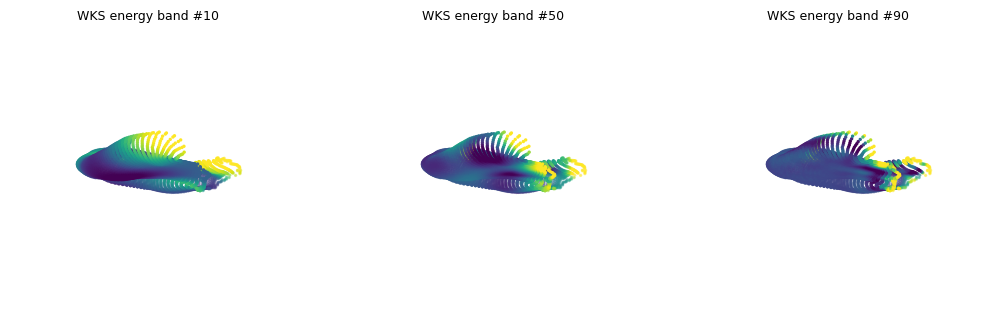

2026-06-09 02:06:19.717 (   0.280s) [    7FCAAF9AF080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


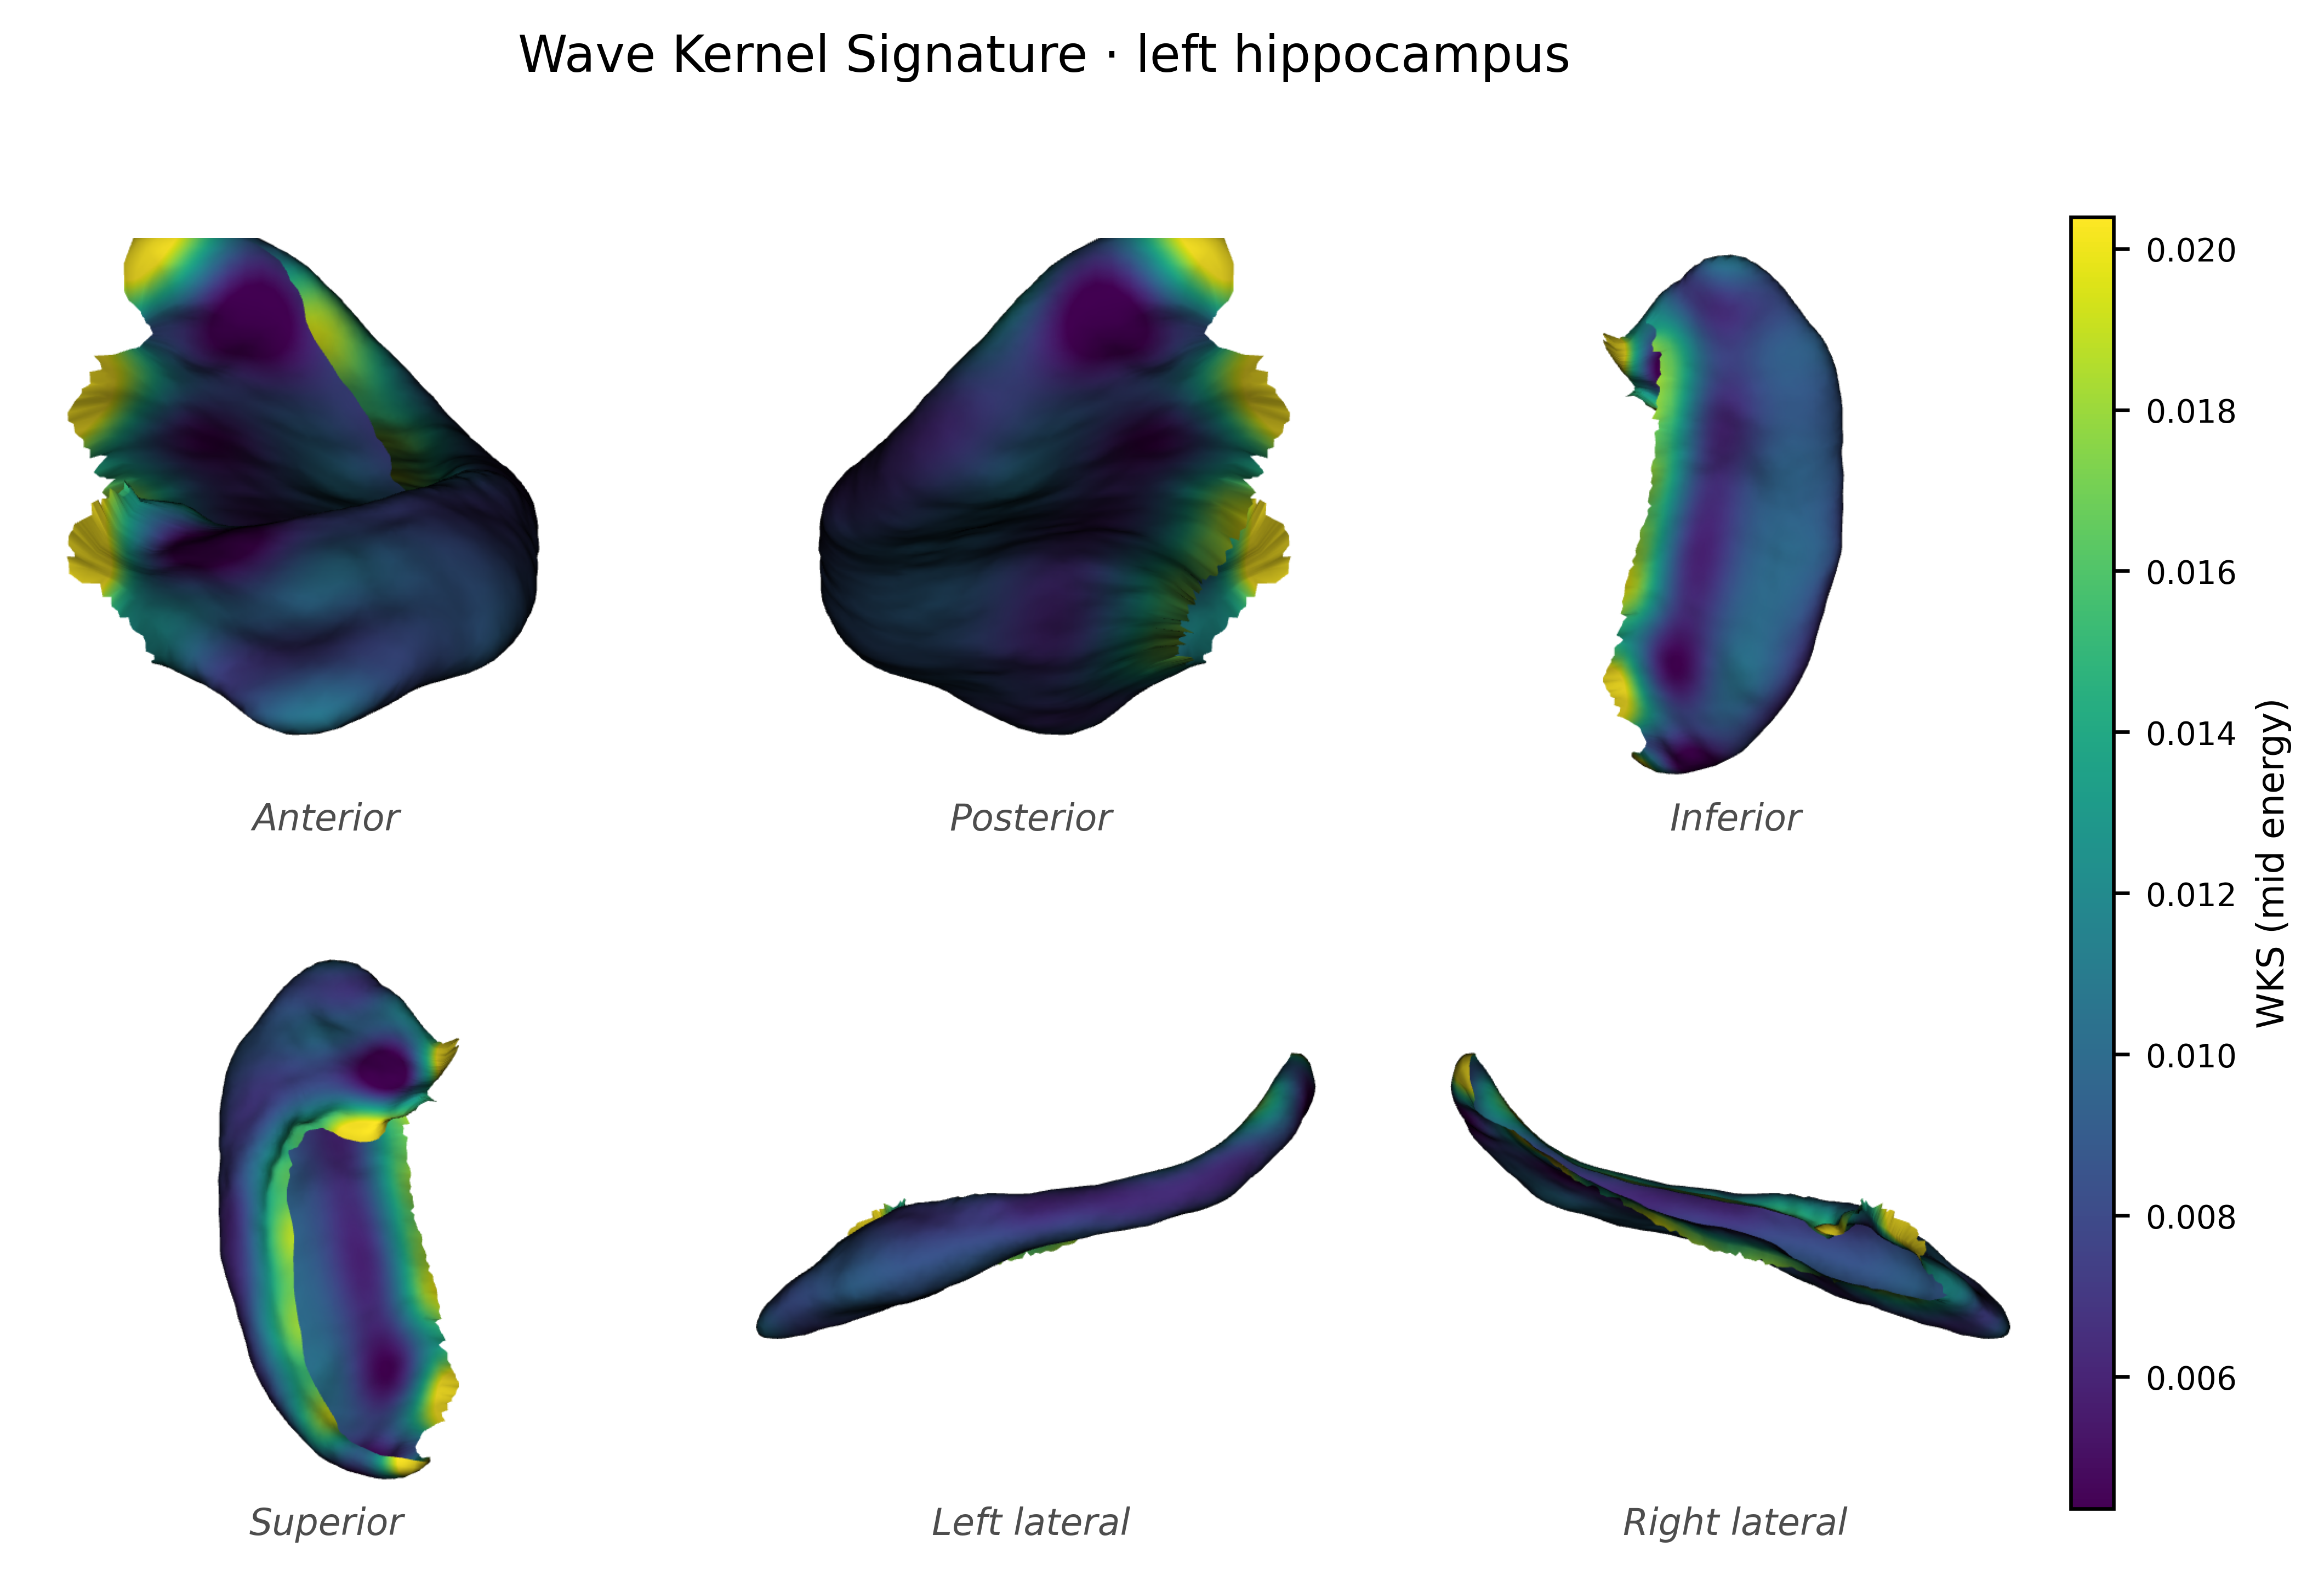

In [2]:
cols = [10, 50, 90]                       # low / mid / high energy bands
V = hipp.vertices
fig = plt.figure(figsize=(10.5, 3.2))
for i, c in enumerate(cols):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    s = wks[:, c]
    ax.scatter(V[:, 0], V[:, 1], V[:, 2], c=s, cmap="viridis", s=2,
               vmin=np.percentile(s, 2), vmax=np.percentile(s, 98))
    ax.set_title(f"WKS energy band #{c}", fontsize=9); ax.set_axis_off(); ax.view_init(20, -70)
plt.tight_layout(); plt.show()

from spectralbrain.viz import plot_surface_sixview
fig = plot_surface_sixview(hipp, scalars=wks[:, 50], cmap="viridis",
                           scalar_bar_title="WKS (mid energy)",
                           title="Wave Kernel Signature · left hippocampus")
plt.show()

## 3. Low-pass vs band-pass, side by side

To make the filtering difference concrete, plot the HKS and WKS "response" at one
vertex as a function of scale/energy. HKS falls monotonically (low-pass); WKS has
a localised bump (band-pass).

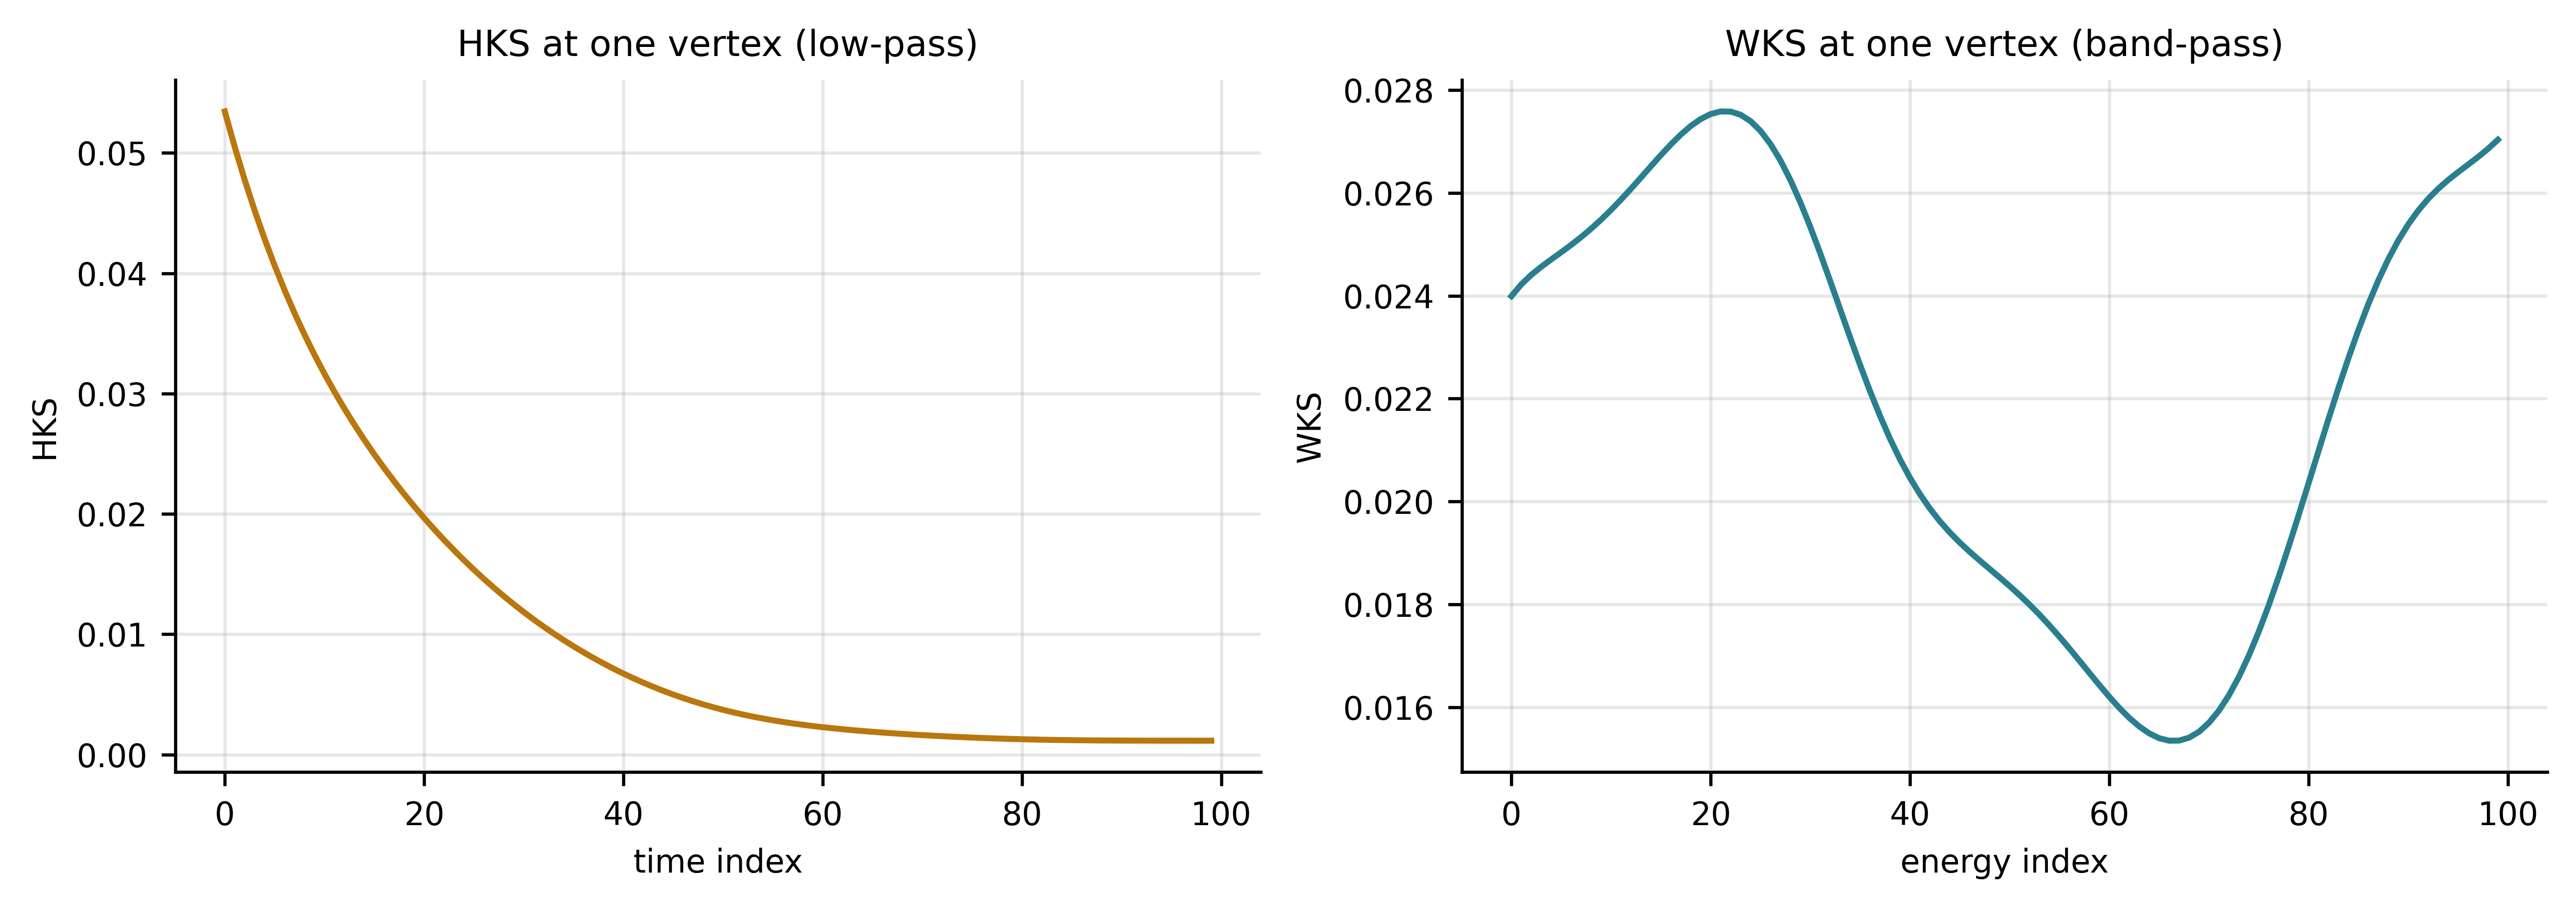

In [3]:
hks = np.asarray(sb.compute_hks(dec, n_times=100))
idx = hipp.n_vertices // 2
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].plot(hks[idx], color="#b9770e"); axes[0].set_title("HKS at one vertex (low-pass)")
axes[0].set_xlabel("time index"); axes[0].set_ylabel("HKS")
axes[1].plot(wks[idx], color="#2a7f8e"); axes[1].set_title("WKS at one vertex (band-pass)")
axes[1].set_xlabel("energy index"); axes[1].set_ylabel("WKS")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. The Global Point Signature: shape as an embedding

GPS (Rustamov 2007) takes a different route. Instead of a multi-scale curve per
vertex, it maps each vertex to a single point in an infinite-dimensional space:

$$\mathrm{GPS}(x) \;=\; \Big(\tfrac{\varphi_1(x)}{\sqrt{\lambda_1}},\, \tfrac{\varphi_2(x)}{\sqrt{\lambda_2}},\, \tfrac{\varphi_3(x)}{\sqrt{\lambda_3}},\, \dots \Big).$$

Two properties make this useful. The scaling by $1/\sqrt{\lambda_k}$ damps
high-frequency noise, and **Euclidean distance in GPS space approximates an
intrinsic distance on the surface** (closely related to the biharmonic distance
of notebook 7). So GPS turns "how far apart are two points *along* the shape" into
an ordinary distance you can feed to clustering or correspondence.

GPS embedding: (8192, 199)  (vertices x coordinates)


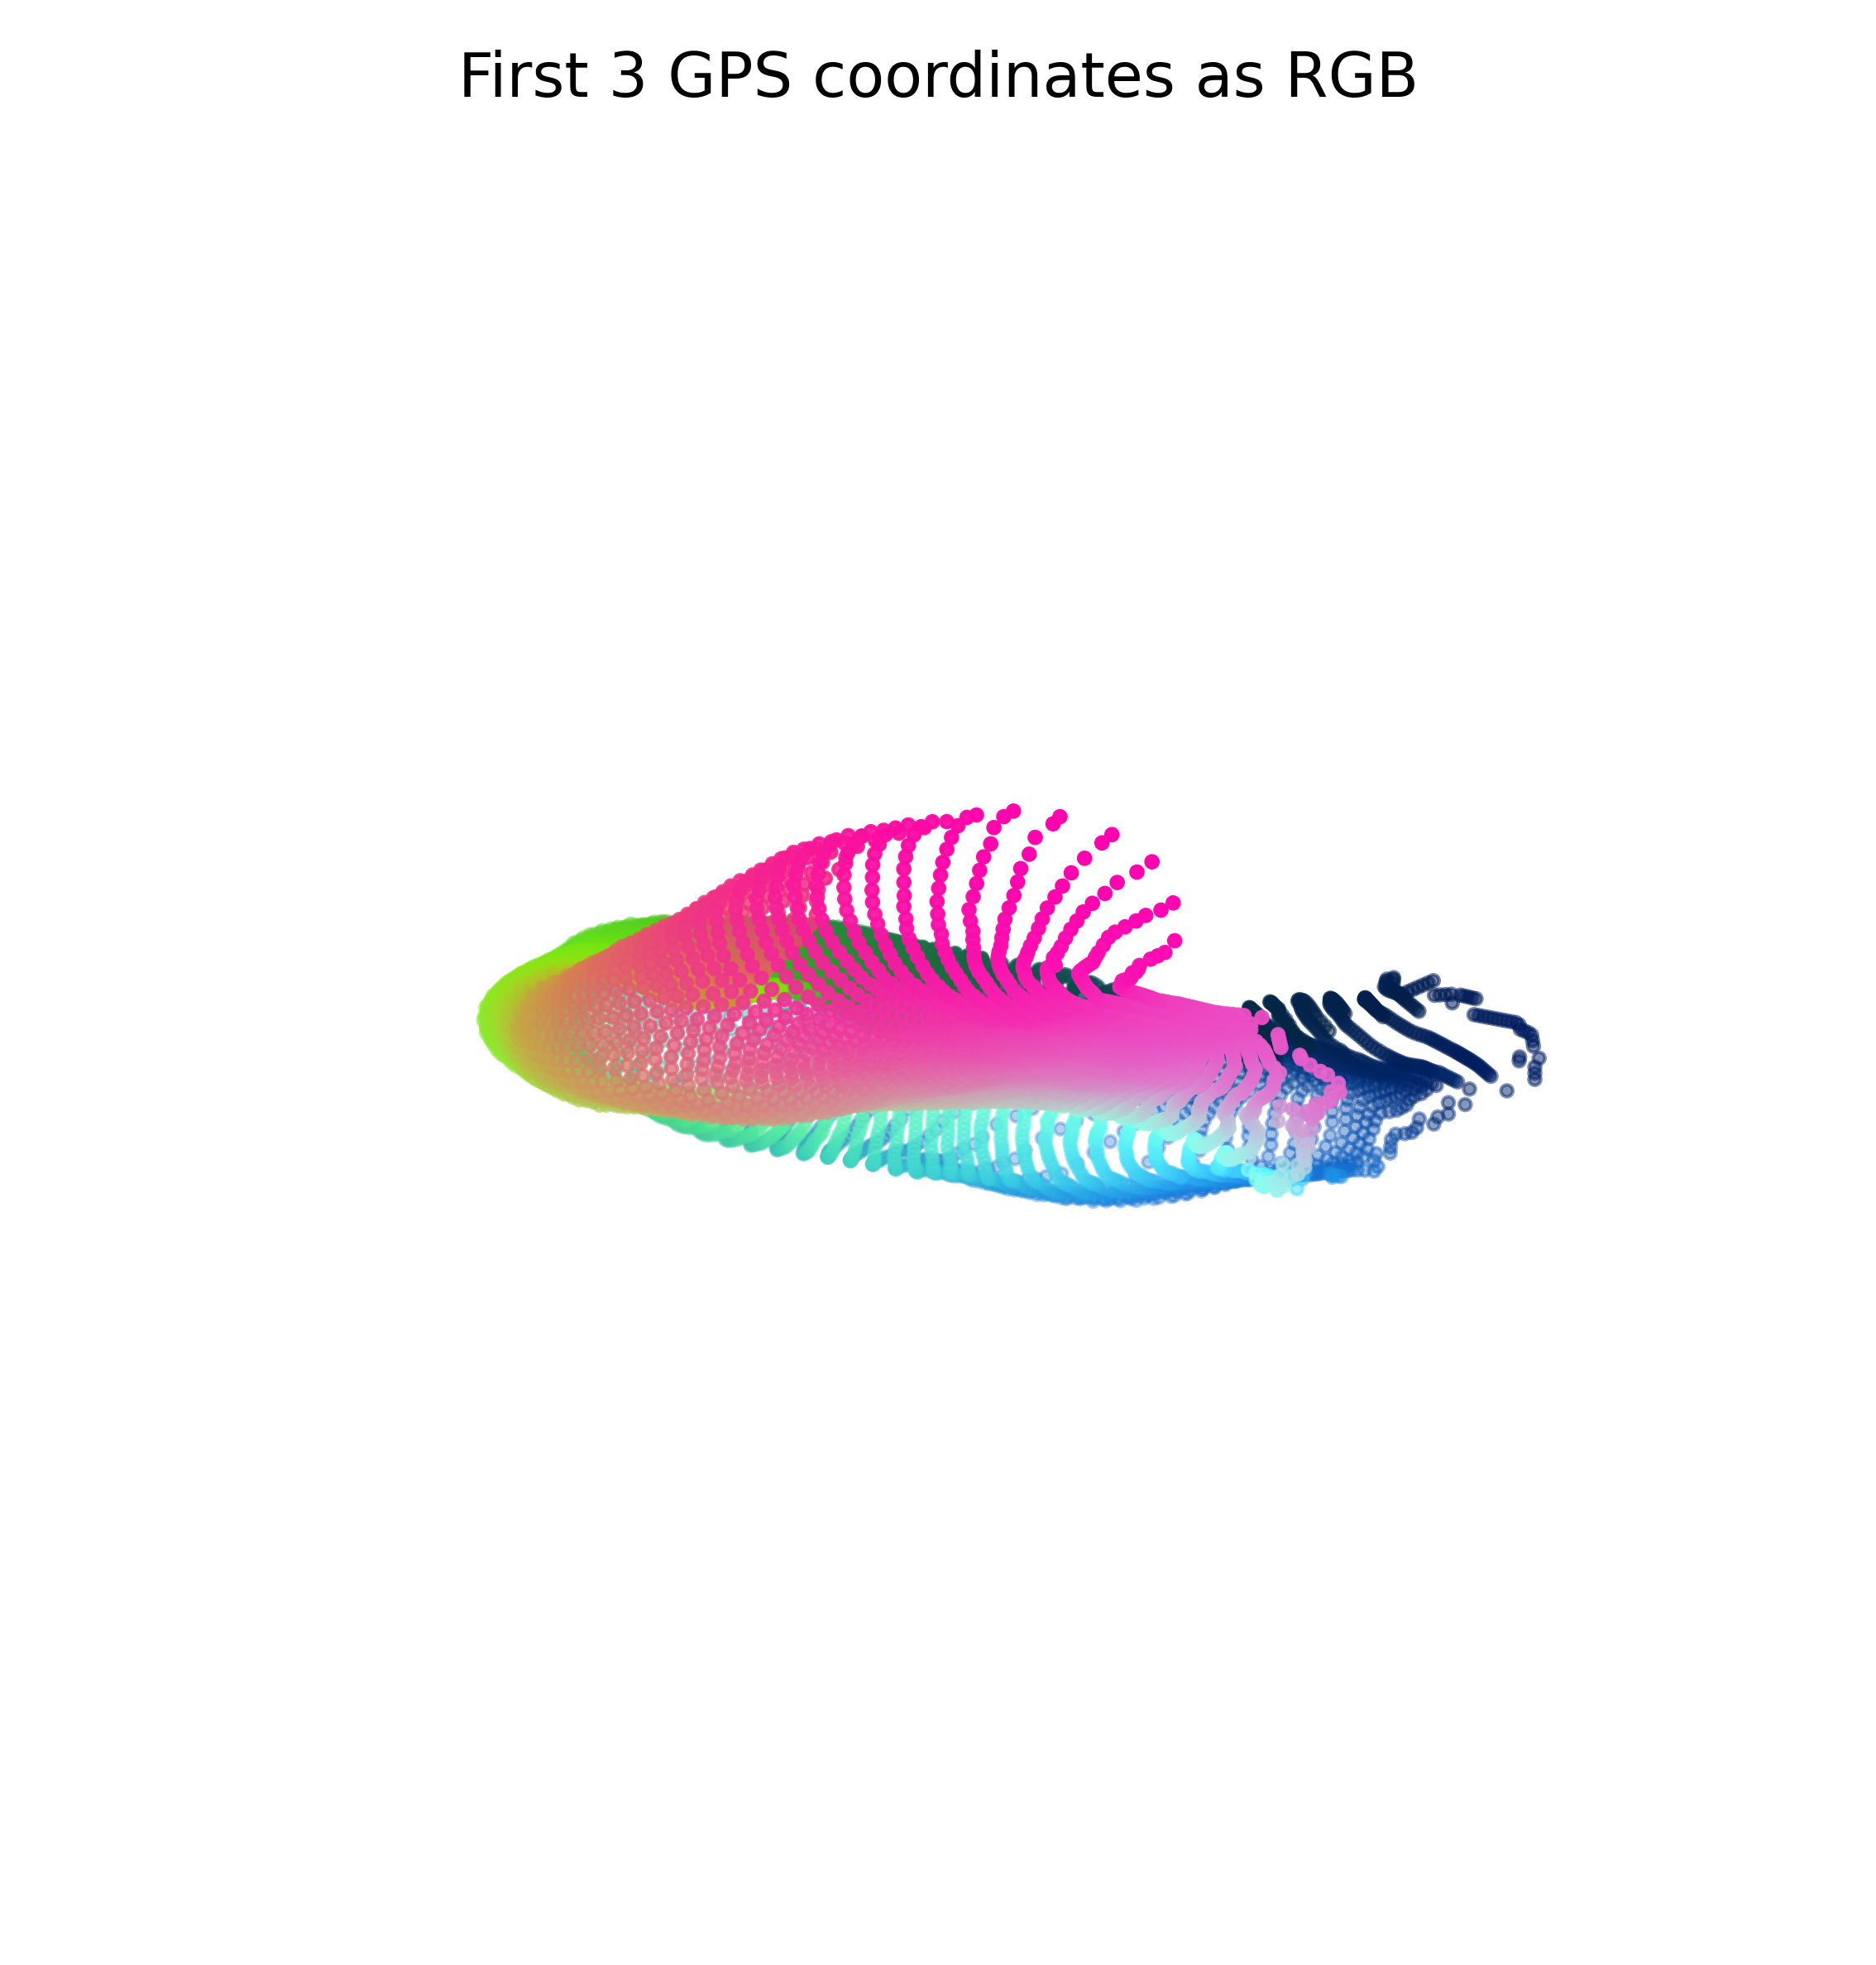

In [4]:
gps = np.asarray(sb.compute_gps(dec))
print(f"GPS embedding: {gps.shape}  (vertices x coordinates)")

# Colour the surface by the first three GPS coordinates (an RGB-like shape code).
g3 = gps[:, :3]
g3 = (g3 - g3.min(0)) / (np.ptp(g3, axis=0) + 1e-12)
fig = plt.figure(figsize=(4.6, 4.0)); ax = fig.add_subplot(111, projection="3d")
ax.scatter(V[:, 0], V[:, 1], V[:, 2], c=g3, s=3)
ax.set_title("First 3 GPS coordinates as RGB"); ax.set_axis_off(); ax.view_init(20, -70)
plt.tight_layout(); plt.show()

## Exercises

1. **Energy budget.** Recompute WKS with `n_energies=50` and `200`. Does the
   localisation of band #50 change? Relate this to the `sigma` parameter.
2. **HKS vs WKS discrimination.** For `sub03_L` and `sub04_L`, average each
   descriptor over vertices and measure the distance between subjects with HKS vs
   with WKS. Which separates them more?
3. **GPS distance.** Pick two vertices on opposite ends of the hippocampus and
   compute their Euclidean distance in GPS space; compare to a near pair. Does GPS
   distance grow with geodesic separation?
4. **Noise damping.** Plot the magnitude of GPS coordinates vs index. Confirm the
   $1/\sqrt{\lambda_k}$ weighting suppresses high-index (noisy) modes.
5. **WKS on a tract.** Foreshadow notebook 6: load a TractSeg bundle as a point
   cloud and compute its WKS. Does band-pass structure appear along the bundle?


## What's next

So far every structure was a closed surface mesh. **Notebook 06** turns to
**point clouds and white-matter tracts**: the robust Laplacian that needs no
faces, the point-cloud spectral signatures (BKS / iBKS), and the numerical
cautions that come with them.
